In [16]:
#scrapping- politifact for fake and real news .

In [17]:
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import requests
import urllib.request
import time

In [18]:
#lists to store scraped data
authors=[]
dates=[]
statements=[]
sources=[]
targets=[]

In [19]:
def scrape_website(page_number):
    page_num = str(page_number)
    url = 'https://www.politifact.com/factchecks/list/?page=' + page_num
    webpage = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(webpage.text, 'html.parser')


    statement_footer = soup.find_all('footer', class_='m-statement__footer')
    statement_quote = soup.find_all('div', class_='m-statement__quote')
    statement_meta = soup.find_all('div', class_='m-statement__meta')
    target = soup.find_all('div', class_='m-statement__meter')


    # Author + Date
    for i in statement_footer:
        text = i.text.strip().split()

        # defensive check
        if len(text) >= 7:
            full_name = text[1] + ' ' + text[2]
            date = text[4] + ' ' + text[5] + ' ' + text[6]

            authors.append(full_name)
            dates.append(date)


    # Statement

    for i in statement_quote:
        a_tag = i.find('a')
        if a_tag:
            statements.append(a_tag.text.strip())


    # Source

    for i in statement_meta:
        a_tag = i.find('a')
        if a_tag:
            sources.append(a_tag.text.strip())


    # Verdict / Target

    for i in target:
        img = i.find('img')
        if img and img.get('alt'):
            targets.append(img.get('alt').strip())


In [20]:
#loop through n-1 webpages to scrap the data
n=100
for i in range(1,n):
  scrape_website(i)

In [21]:

#creating the dataframe
min_len=min(len(authors),len(dates),len(statements),len(sources),len(targets))
data=pd.DataFrame({
'authors':authors[:min_len],
'dates':dates[:min_len],
'statements':statements[:min_len],
'sources':sources[:min_len],
'targets':targets[:min_len]
})
data

,authors,dates,statements,sources,targets
0,Louis Jacobson,"May 8, 2026",Gasoline prices have “come down very substanti...,Donald Trump,false
1,Samantha Putterman,"May 8, 2026",Congress passed the 1965 Voting Rights Act bec...,Byron Donalds,false
2,Maria Briceño,"May 8, 2026",Republicans “want you to pay $1 Billion for a ...,Marcy Kaptur,mostly-true
3,Conor Amendola,"May 7, 2026",Proposed data centers in New York state would ...,Liz Krueger,barely-true
4,Louis Jacobson,"May 7, 2026",“California only has ‘enough’ oil and gas supp...,X posts,false
...,...,...,...,...,...
2965,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false
2966,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false
2967,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire
2968,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire


In [22]:
data.tail()

,authors,dates,statements,sources,targets
2965,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false
2966,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false
2967,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire
2968,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire
2969,Ciara O'Rourke,"August 24, 2023",U.S. Navy SEALs rescued 807 children who were ...,Instagram posts,false


In [23]:
#function to get binary number from the target
def BinaryTarget(targets):
  if targets=='true' or targets=='mostly-true' or targets=='half-true':
    return 1
  else:
    return 0

In [24]:
data

,authors,dates,statements,sources,targets
0,Louis Jacobson,"May 8, 2026",Gasoline prices have “come down very substanti...,Donald Trump,false
1,Samantha Putterman,"May 8, 2026",Congress passed the 1965 Voting Rights Act bec...,Byron Donalds,false
2,Maria Briceño,"May 8, 2026",Republicans “want you to pay $1 Billion for a ...,Marcy Kaptur,mostly-true
3,Conor Amendola,"May 7, 2026",Proposed data centers in New York state would ...,Liz Krueger,barely-true
4,Louis Jacobson,"May 7, 2026",“California only has ‘enough’ oil and gas supp...,X posts,false
...,...,...,...,...,...
2965,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false
2966,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false
2967,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire
2968,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire


In [25]:
#function to get a binary label true(real) pr false(fake) from the target
def FinalTarget(targets):
  if targets=="true" or targets=="mostly-true" or targets=="half-true":
    return 'Real'
  else:
    return "Fake"


In [26]:
data['FinalTarget']=data['targets'].apply(FinalTarget)
data['BinaryTarget']=data['targets'].apply(BinaryTarget)

In [27]:
data

,authors,dates,statements,sources,targets,FinalTarget,BinaryTarget
0,Louis Jacobson,"May 8, 2026",Gasoline prices have “come down very substanti...,Donald Trump,false,Fake,0
1,Samantha Putterman,"May 8, 2026",Congress passed the 1965 Voting Rights Act bec...,Byron Donalds,false,Fake,0
2,Maria Briceño,"May 8, 2026",Republicans “want you to pay $1 Billion for a ...,Marcy Kaptur,mostly-true,Real,1
3,Conor Amendola,"May 7, 2026",Proposed data centers in New York state would ...,Liz Krueger,barely-true,Fake,0
4,Louis Jacobson,"May 7, 2026",“California only has ‘enough’ oil and gas supp...,X posts,false,Fake,0
...,...,...,...,...,...,...,...
2965,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false,Fake,0
2966,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false,Fake,0
2967,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire,Fake,0
2968,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire,Fake,0


# Machine Learning Pipeline
The following sections implement a standard ML pipeline on the scraped fact-check statements.

In [28]:
import pandas as pd
import numpy as np
import spacy
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


### 1. Data Preparation & Cleaning

In [29]:
# Clean the data
df = data.copy()
df = df.dropna(subset=['statements', 'BinaryTarget'])
df = df[df['statements'].astype(str).str.len() > 10]

X_raw = df['statements'].astype(str)
y = df['BinaryTarget'].astype(int).values

print(f"Total valid samples: {len(df)}")
print(f"Class Distribution: Real (1): {sum(y==1)}, Fake (0): {sum(y==0)}")


Total valid samples: 2970
Class Distribution: Real (1): 317, Fake (0): 2653


### 2. Feature Engineering (NLP)

In [30]:
# Load spaCy model for preprocessing
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    doc = nlp(text.lower())
    # Remove stop words and punctuation, keep alpha
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return " ".join(tokens)

print("Preprocessing text (this might take a minute)...")
X_processed = X_raw.apply(preprocess_text)

# TF-IDF Vectorization
print("Vectorizing text...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_features = vectorizer.fit_transform(X_processed)


Preprocessing text (this might take a minute)...
Vectorizing text...


In [31]:
# Tokenization + sequence padding for CNN/RNN models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

MAX_WORDS = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_processed)
sequences = tokenizer.texts_to_sequences(X_processed)
X_seq = pad_sequences(sequences, maxlen=MAX_LEN)

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Saved tokenizer to tokenizer.pkl')

Saved tokenizer to tokenizer.pkl


### 3 & 4. Model Setup & K-Fold Cross-Validation Training

In [32]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

models_to_run = {
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42, class_weight='balanced'),
    "SVM": SVC(kernel='linear', C=0.5, random_state=42, class_weight='balanced')
}

model_metrics = {}

for name, model in models_to_run.items():
    print(f"Training {name} with {N_SPLITS}-Fold CV & SMOTE...")
    fold_metrics = {'accuracy': [], 'f1': [], 'precision': [], 'recall': []}

    for train_index, test_index in skf.split(X_features, y):
        X_train, X_test = X_features[train_index], X_features[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Apply SMOTE pipeline or handle Naive Bayes
        if name == "Naive Bayes":
            # Convert to float to avoid issues with absolute values in some versions
            X_train_final = np.abs(X_train).astype(float)
            clf = model
            clf.fit(X_train_final, y_train)
        else:
            smote_pipeline = ImbPipeline([
                ('sampler', SMOTE(random_state=42, k_neighbors=3)),
                ('classifier', model)
            ])
            smote_pipeline.fit(X_train, y_train)
            clf = smote_pipeline

        y_pred = clf.predict(X_test)

        fold_metrics['accuracy'].append(accuracy_score(y_test, y_pred))
        fold_metrics['f1'].append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        fold_metrics['precision'].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        fold_metrics['recall'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))

    model_metrics[name] = {
        "Model": name,
        "Accuracy": np.mean(fold_metrics['accuracy']) * 100,
        "F1-Score": np.mean(fold_metrics['f1']),
        "Precision": np.mean(fold_metrics['precision']),
        "Recall": np.mean(fold_metrics['recall'])
    }

results_df = pd.DataFrame(list(model_metrics.values()))
display(results_df)


Training Naive Bayes with 5-Fold CV & SMOTE...
Training Decision Tree with 5-Fold CV & SMOTE...
Training Logistic Regression with 5-Fold CV & SMOTE...
Training SVM with 5-Fold CV & SMOTE...


,Model,Accuracy,F1-Score,Precision,Recall
0,Naive Bayes,89.494949,0.846933,0.863245,0.894949
1,Decision Tree,85.488215,0.862477,0.872159,0.854882
2,Logistic Regression,87.811448,0.880691,0.883784,0.878114
3,SVM,87.508418,0.876177,0.877596,0.875084


### 5. Visualization

/tmp/ipykernel_7431/640713885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


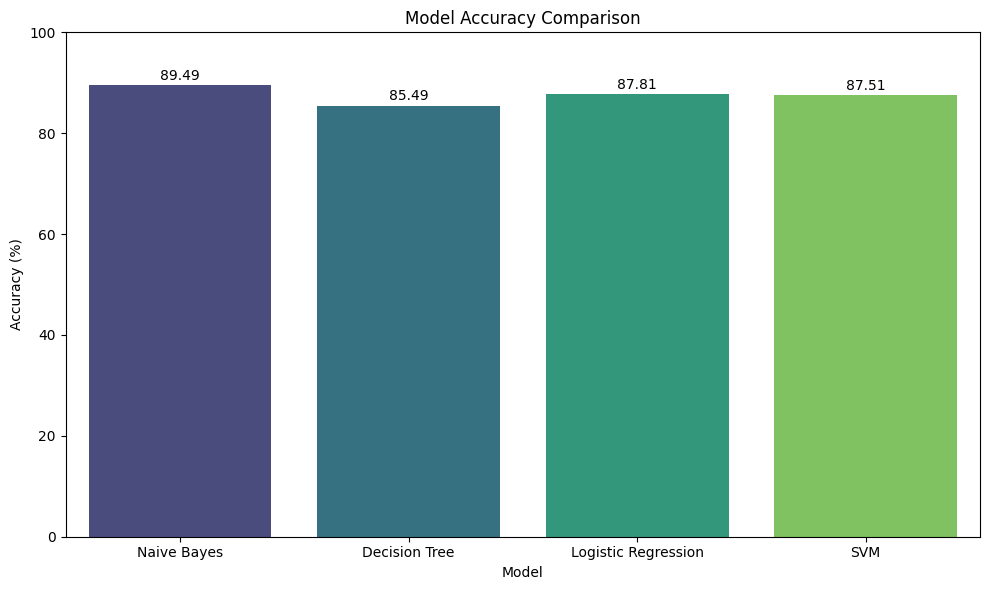

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 1, round(row.Accuracy, 2), color='black', ha="center")
plt.tight_layout()
plt.show()


### 6. Deep Learning Models (ANN & RNN)

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

#### ANN Model Definition

In [44]:
def build_ann_model(vocab_size, input_length):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100, input_length=input_length),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Binary classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#### RNN (LSTM) Model Definition

In [45]:
def build_lstm_model(vocab_size, input_length):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100, input_length=input_length),
        LSTM(128, return_sequences=True),
        Dropout(0.5),
        LSTM(64),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [46]:
# Removed: get_ipython().run_cell_id('51d24321') caused AttributeError.

In [47]:
# Removed: get_ipython().run_cell_id('51d24321') caused AttributeError.

#### Training and Evaluation of Deep Learning Models

In [48]:
# Ensure MAX_WORDS and MAX_LEN are defined from previous cells
# If you encountered an error with X_processed not defined earlier, please run the cells
# 'yLhELaoOBKf6' and 'uuIhc2ekBKf7' to generate X_processed and X_seq.

from sklearn.model_selection import StratifiedKFold # Added for skf definition

N_SPLITS = 5 # Define N_SPLITS here to ensure it's accessible
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42) # Added for skf definition

dl_model_metrics = {}

# Deep Learning Models
for model_type in ["ANN", "LSTM"]:
    print(f"\nTraining {model_type} with {N_SPLITS}-Fold CV...")
    fold_metrics = {'accuracy': [], 'f1': [], 'precision': [], 'recall': []}

    for fold, (train_index, test_index) in enumerate(skf.split(X_seq, y)):
        print(f"  Fold {fold+1}/{N_SPLITS}")
        X_train_dl, X_test_dl = X_seq[train_index], X_seq[test_index]
        y_train_dl, y_test_dl = y[train_index], y[test_index]

        if model_type == "ANN":
            model = build_ann_model(MAX_WORDS + 1, MAX_LEN)
        else: # LSTM
            model = build_lstm_model(MAX_WORDS + 1, MAX_LEN)

        # Calculate class weights for imbalanced data
        neg, pos = np.bincount(y_train_dl)
        total = neg + pos
        class_weight = {0: (1/neg)*(total/2.0), 1: (1/pos)*(total/2.0)}

        history = model.fit(
            X_train_dl, y_train_dl,
            epochs=5, # Can adjust epochs based on performance
            batch_size=32,
            validation_split=0.1, # Using a small validation split within train data
            verbose=0, # Set to 1 or 2 for more output
            class_weight=class_weight
        )

        y_pred_proba = model.predict(X_test_dl, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

        fold_metrics['accuracy'].append(accuracy_score(y_test_dl, y_pred))
        fold_metrics['f1'].append(f1_score(y_test_dl, y_pred, average='weighted', zero_division=0))
        fold_metrics['precision'].append(precision_score(y_test_dl, y_pred, average='weighted', zero_division=0))
        fold_metrics['recall'].append(recall_score(y_test_dl, y_pred, average='weighted', zero_division=0))

    dl_model_metrics[model_type] = {
        "Model": model_type,
        "Accuracy": np.mean(fold_metrics['accuracy']) * 100,
        "F1-Score": np.mean(fold_metrics['f1']),
        "Precision": np.mean(fold_metrics['precision']),
        "Recall": np.mean(fold_metrics['recall'])
    }


Training ANN with 5-Fold CV...
  Fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Fold 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Fold 3/5


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Fold 4/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Fold 5/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Combined Results and Visualization

,Model,Accuracy,F1-Score,Precision,Recall
0,Naive Bayes,89.494949,0.846933,0.863245,0.894949
1,Decision Tree,85.488215,0.862477,0.872159,0.854882
2,Logistic Regression,87.811448,0.880691,0.883784,0.878114
3,SVM,87.508418,0.876177,0.877596,0.875084
4,ANN,85.690236,0.863824,0.874957,0.856902
5,LSTM,85.084175,0.856211,0.862888,0.850842


/tmp/ipykernel_7431/3197387315.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=final_results_df, palette='viridis')


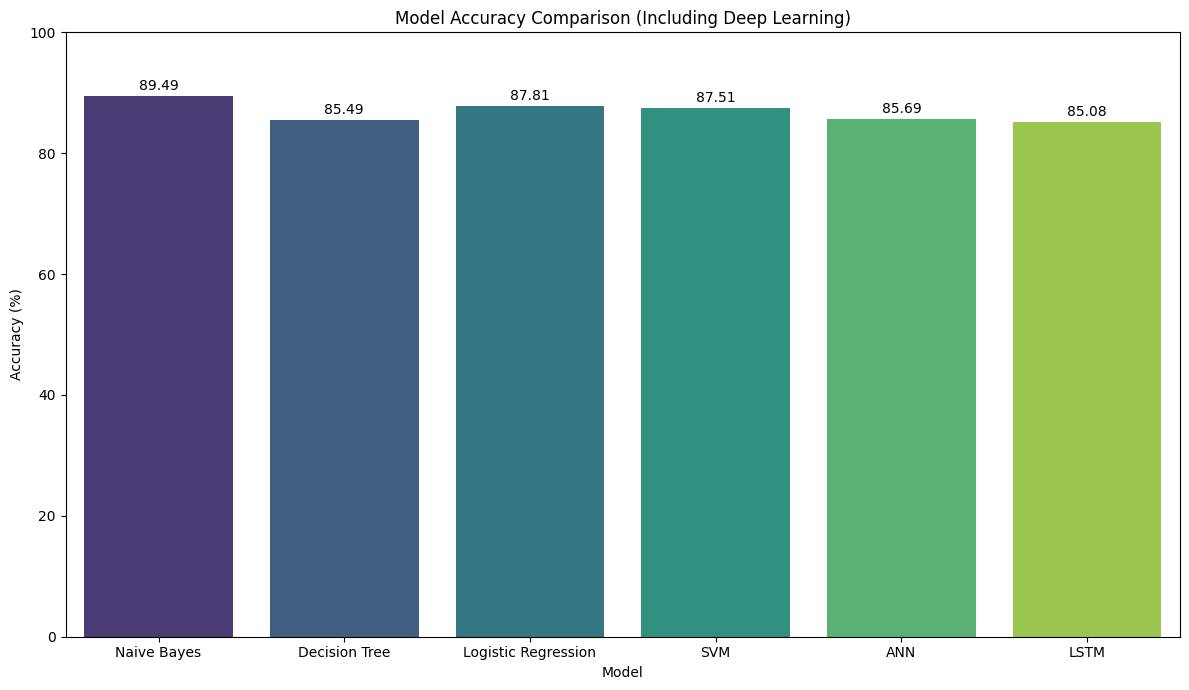

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dl_results_df = pd.DataFrame(list(dl_model_metrics.values()))
final_results_df = pd.concat([results_df, dl_results_df], ignore_index=True)
display(final_results_df)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=final_results_df, palette='viridis')
plt.title('Model Accuracy Comparison (Including Deep Learning)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for index, row in final_results_df.iterrows():
    plt.text(index, row.Accuracy + 1, round(row.Accuracy, 2), color='black', ha="center")
plt.tight_layout()
plt.show()